In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("15-gym_crowdedness.csv")

In [4]:
df.shape

(62184, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [6]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [7]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [9]:
df['date'] = pd.to_datetime(df['date'],utc=True)

In [10]:
df['date']

0       2015-08-15 00:00:11+00:00
1       2015-08-15 00:20:14+00:00
2       2015-08-15 00:30:15+00:00
3       2015-08-15 00:40:16+00:00
4       2015-08-15 00:50:17+00:00
                   ...           
62179   2017-03-19 01:42:28+00:00
62180   2017-03-19 01:52:35+00:00
62181   2017-03-19 02:02:40+00:00
62182   2017-03-19 02:12:47+00:00
62183   2017-03-19 02:22:51+00:00
Name: date, Length: 62184, dtype: datetime64[ns, UTC]

In [12]:
df['year'] = df['date'].dt.year

In [13]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17,2015
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17,2015
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17,2015


In [15]:
df.year.unique()

array([2015, 2016, 2017], dtype=int32)

In [16]:
df.drop('date',axis=1,inplace=True)

In [17]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


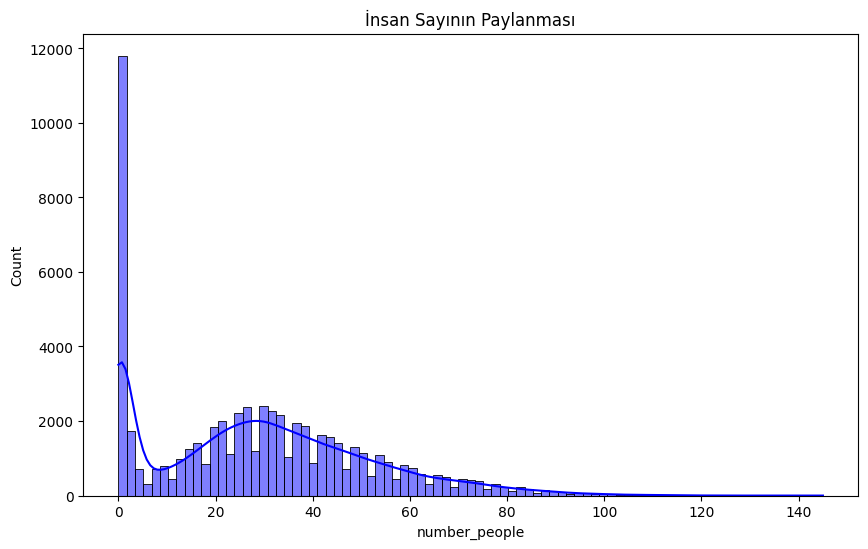

In [18]:
\

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='number_people', kde=True, color='blue')
plt.title('İnsan Sayının Paylanması')
plt.show()

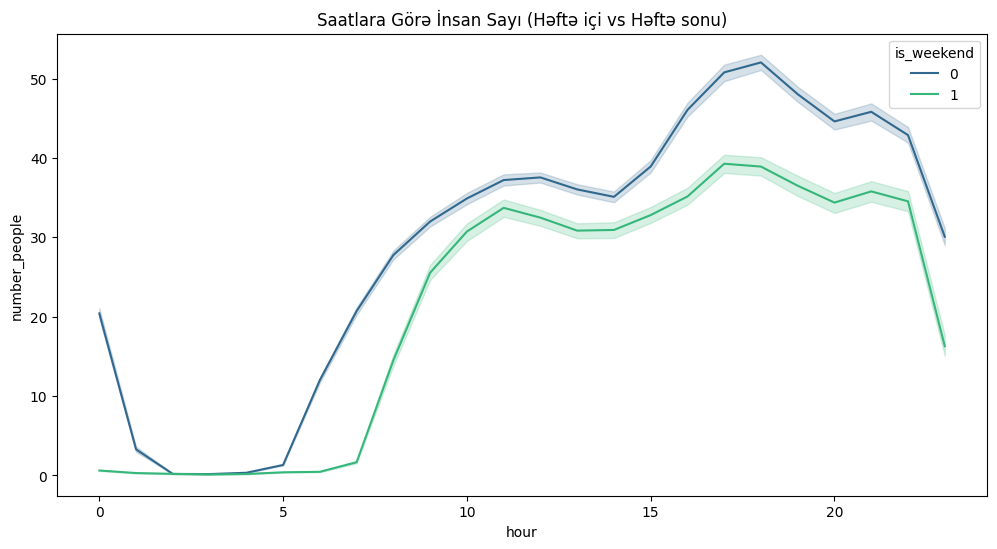

In [19]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='hour', y='number_people', hue='is_weekend', palette='viridis')
plt.title('Saatlara Görə İnsan Sayı (Həftə içi vs Həftə sonu)')
plt.show()

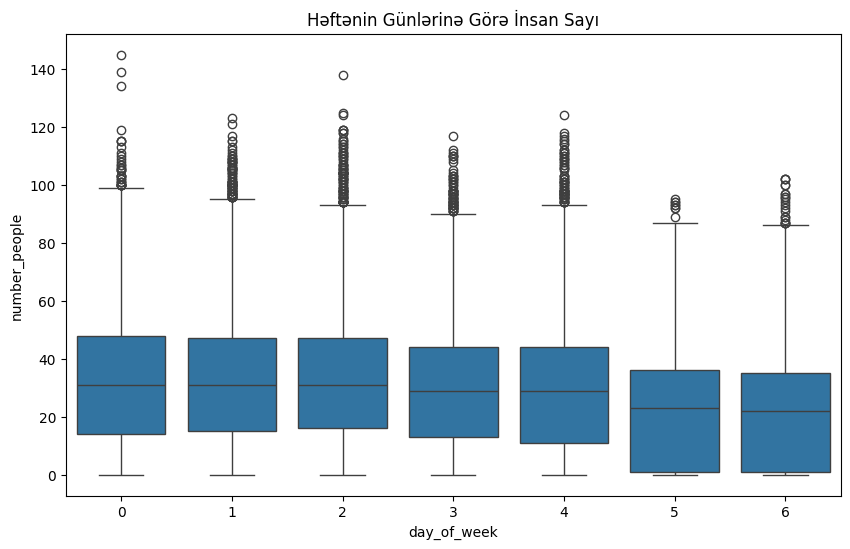

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='day_of_week', y='number_people')
plt.title('Həftənin Günlərinə Görə İnsan Sayı')
plt.show()

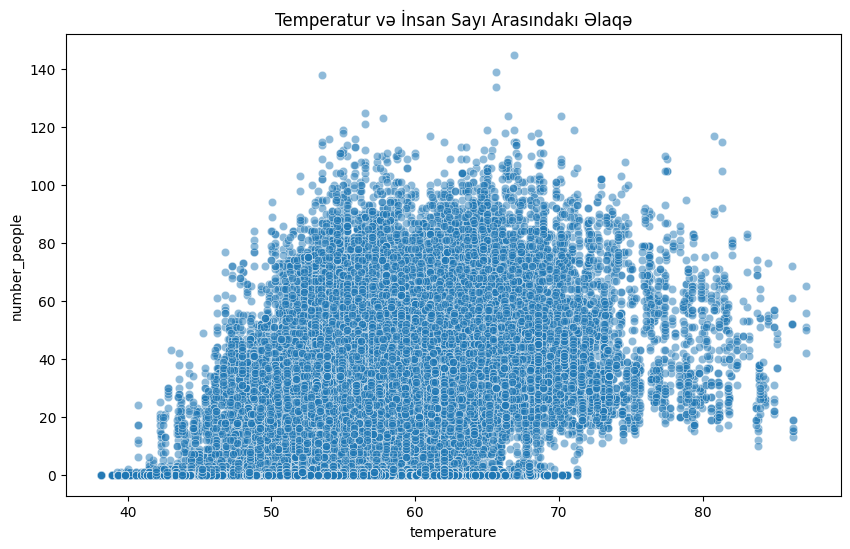

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperature', y='number_people', alpha=0.5)
plt.title('Temperatur və İnsan Sayı Arasındakı Əlaqə')
plt.show()

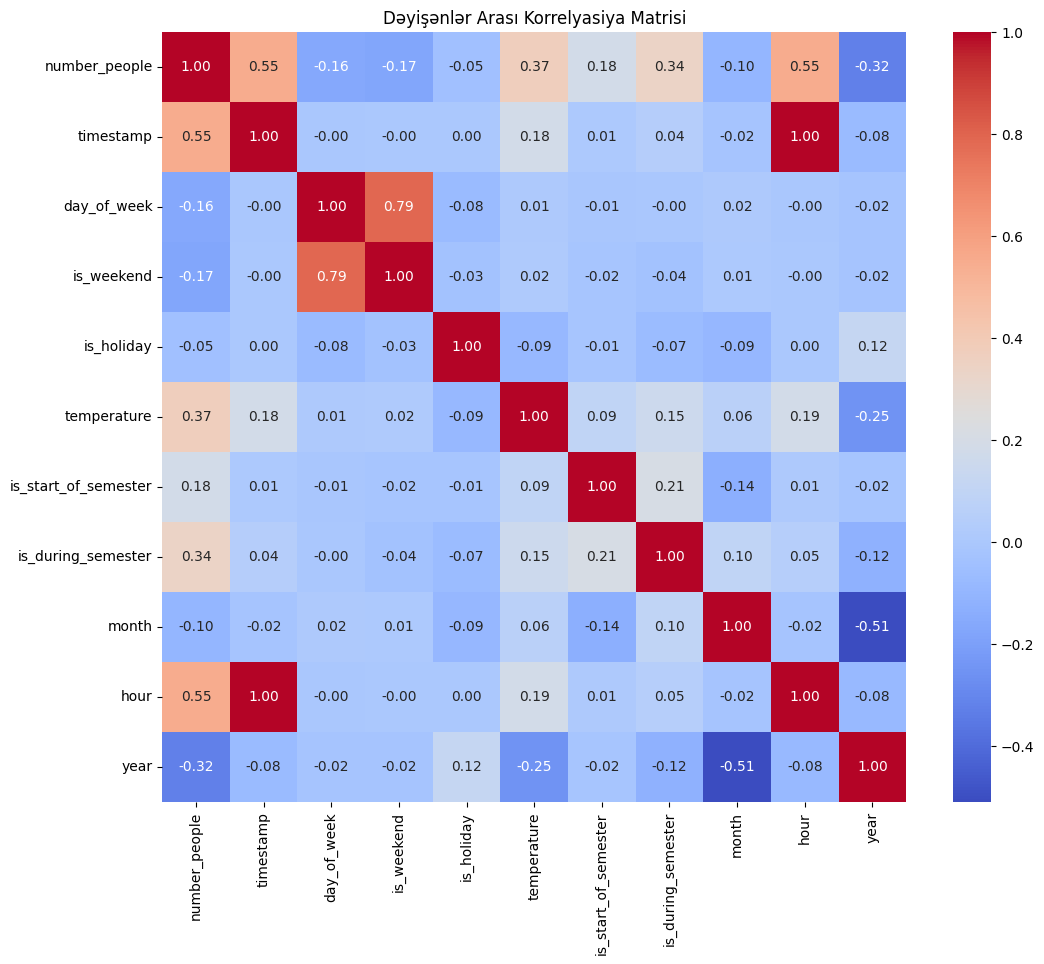

In [22]:
plt.figure(figsize=(12, 10))

correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Dəyişənlər Arası Korrelyasiya Matrisi')
plt.show()

In [23]:
df.drop('timestamp',axis=1,inplace=True)

In [24]:
#dependent & independent features

In [25]:
X = df.drop('number_people', axis = 1)
y = df['number_people']

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=15)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [29]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [30]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso": Lasso(),
    "Ridge" : Ridge(),
    "K-Neighbors Regressor"  : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor()
}

In [31]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("RMSE :", model_train_rmse)
    print("Mean Absolute Error :", model_train_mae)
    print("R2 Score :", model_train_r2)

    print("-----------------------------")
    
    print("Evaluation for Test Set")
    print("RMSE :", model_test_rmse)
    print("Mean Absolute Error :", model_test_mae)
    print("R2 Score :", model_test_r2)

    print("-----------------------------")
    print("\n")

LinearRegression()
Evaluation for Training Set
RMSE : 14.322500408269727
Mean Absolute Error : 10.733469936454325
R2 Score : 0.5999639521710997
-----------------------------
Evaluation for Test Set
RMSE : 14.45063290337055
Mean Absolute Error : 10.779752371029561
R2 Score : 0.5989271376662775
-----------------------------


Lasso()
Evaluation for Training Set
RMSE : 14.569122351126817
Mean Absolute Error : 10.945189874221992
R2 Score : 0.5860687429058037
-----------------------------
Evaluation for Test Set
RMSE : 14.703511215751082
Mean Absolute Error : 10.970594902476911
R2 Score : 0.5847671974050243
-----------------------------


Ridge()
Evaluation for Training Set
RMSE : 14.322500413912243
Mean Absolute Error : 10.733479178820698
R2 Score : 0.5999639518559019
-----------------------------
Evaluation for Test Set
RMSE : 14.450633329986026
Mean Absolute Error : 10.77975955902301
R2 Score : 0.5989271139851151
-----------------------------


KNeighborsRegressor()
Evaluation for Traini

In [32]:
#hyper paramate tuning
knn_params = {"n_neighbors" : [2,3,10,20,40,50]}
rf_params = {
        "max_depth" : [5,8,10,15,None],
        "max_features" : ["sqrt", "log2", 5, 7, 10],
        "min_samples_split" : [2, 8, 12, 20],
        "n_estimators" : [100, 200, 500, 1000]
}

In [33]:
from sklearn.model_selection import RandomizedSearchCV

In [34]:
randomcv_models = [
    ("KNN", KNeighborsRegressor(), knn_params),
    ("RF", RandomForestRegressor(), rf_params)
        ]

In [35]:
for name, model, params in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter = 100, cv = 3, n_jobs = -1)
    randomcv.fit(X_train, y_train)
    print("best params for :", name, randomcv.best_params_)

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=100. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


best params for : KNN {'n_neighbors': 2}
best params for : RF {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 5, 'max_depth': None}


In [36]:
# best params for : KNN {'n_neighbors': 2}
# best params for : RF {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}

In [37]:
models = {
    "K-Neighbors Regressor"  : KNeighborsRegressor(n_neighbors=2),
    "Random Forest Regressor" : RandomForestRegressor(n_estimators=500,
                                                     min_samples_split=2,
                                                      max_features=7,
                                                      max_depth = None)
}

In [38]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

    print(list(models.values())[i])

    print("Evaluation for Training Set")
    print("RMSE :", model_train_rmse)
    print("Mean Absolute Error :", model_train_mae)
    print("R2 Score :", model_train_r2)

    print("-----------------------------")
    
    print("Evaluation for Test Set")
    print("RMSE :", model_test_rmse)
    print("Mean Absolute Error :", model_test_mae)
    print("R2 Score :", model_test_r2)

    print("-----------------------------")
    print("\n")

KNeighborsRegressor(n_neighbors=2)
Evaluation for Training Set
RMSE : 5.459929507262949
Mean Absolute Error : 3.5543762597023885
R2 Score : 0.9418652897023468
-----------------------------
Evaluation for Test Set
RMSE : 6.901495818935785
Mean Absolute Error : 4.6316737424417855
R2 Score : 0.9085179266857696
-----------------------------


RandomForestRegressor(max_features=7, n_estimators=500)
Evaluation for Training Set
RMSE : 4.710336527721257
Mean Absolute Error : 3.1966044856261786
R2 Score : 0.9567321501641001
-----------------------------
Evaluation for Test Set
RMSE : 6.416749217290188
Mean Absolute Error : 4.291698365181161
R2 Score : 0.9209176305831347
-----------------------------


